# Insights about the dataset

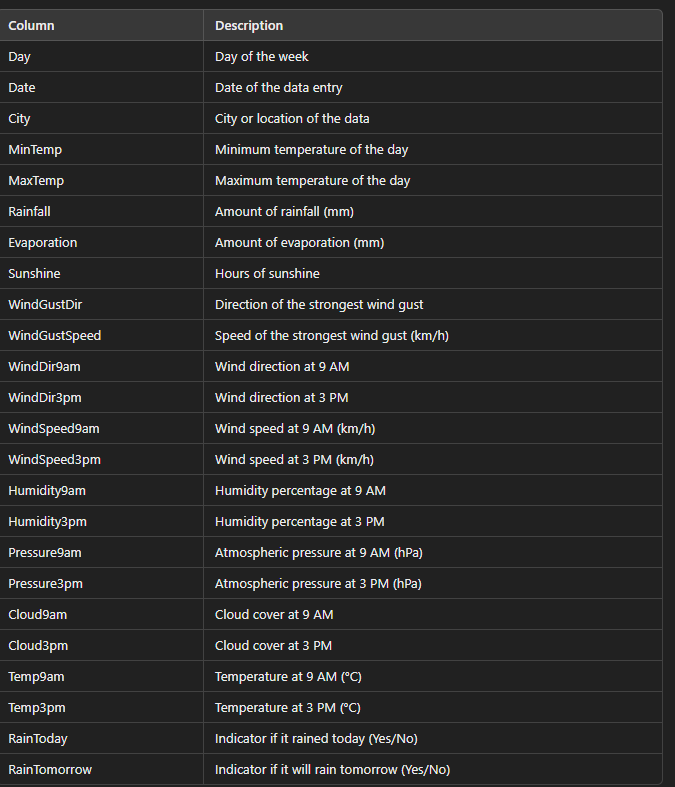

# Evaluating features importance

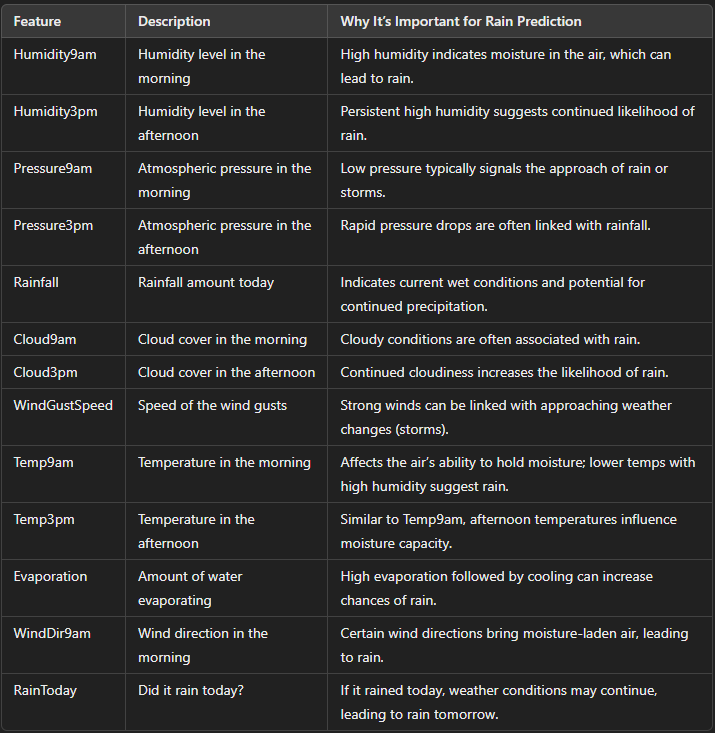

# Necessary imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [10]:
rain_df = pd.read_csv('rain-prediction-challenge/train.csv')
print(rain_df.head())


   Day        Date            City  MinTemp  MaxTemp  Rainfall  Evaporation  \
0    0  2010-01-01         Algiers     19.4     31.9       5.0          NaN   
1    1  2010-01-02           Setif     18.6     29.1      12.4          NaN   
2    2  2010-01-03  Sidi Bel Abbes     12.2     29.7       0.0          NaN   
3    3  2010-01-04          Skikda     14.8     32.8       0.0          NaN   
4    4  2010-01-05          Skikda     15.0     35.8       0.0          NaN   

   Sunshine WindGustDir  WindGustSpeed  ... Humidity9am Humidity3pm  \
0       NaN         NNE           39.0  ...        70.0        40.0   
1       NaN           W           56.0  ...        88.0        48.0   
2       NaN           W           30.0  ...        57.0        32.0   
3       NaN          SW           30.0  ...        55.0        24.0   
4       NaN           W           46.0  ...        46.0        13.0   

   Pressure9am  Pressure3pm  Cloud9am  Cloud3pm  Temp9am  Temp3pm  RainToday  \
0       1012.2    

In [8]:
description_full = rain_df.describe(include='all')
print(description_full)

                 Day        Date    City       MinTemp       MaxTemp  \
count   76672.000000       76672   76672  76453.000000  76478.000000   
unique           NaN        1737      10           NaN           NaN   
top              NaN  2010-01-01  Skikda           NaN           NaN   
freq             NaN          45    7864           NaN           NaN   
mean    38335.500000         NaN     NaN     11.894520     22.833249   
std     22133.444257         NaN     NaN      6.361629      6.845794   
min         0.000000         NaN     NaN     -8.200000     -4.100000   
25%     19167.750000         NaN     NaN      7.400000     17.800000   
50%     38335.500000         NaN     NaN     11.700000     22.300000   
75%     57503.250000         NaN     NaN     16.500000     27.600000   
max     76671.000000         NaN     NaN     31.400000     48.100000   

            Rainfall   Evaporation      Sunshine WindGustDir  WindGustSpeed  \
count   76672.000000  46996.000000  44312.000000       7

In [15]:
rain_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76672 entries, 0 to 76671
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Day            76672 non-null  int64  
 1   Date           76672 non-null  object 
 2   City           76672 non-null  object 
 3   MinTemp        76453 non-null  float64
 4   MaxTemp        76478 non-null  float64
 5   Rainfall       76672 non-null  float64
 6   Evaporation    46996 non-null  float64
 7   Sunshine       44312 non-null  float64
 8   WindGustDir    71517 non-null  object 
 9   WindGustSpeed  71554 non-null  float64
 10  WindDir9am     70965 non-null  object 
 11  WindDir3pm     75134 non-null  object 
 12  WindSpeed9am   76081 non-null  float64
 13  WindSpeed3pm   75872 non-null  float64
 14  Humidity9am    75811 non-null  float64
 15  Humidity3pm    75834 non-null  float64
 16  Pressure9am    69106 non-null  float64
 17  Pressure3pm    69081 non-null  float64
 18  Cloud9

In [17]:
rain_df['Date'] = pd.to_datetime(rain_df['Date'])
rain_df.set_index('Date', inplace=True)


### Line Chart for Temperature & Pressure

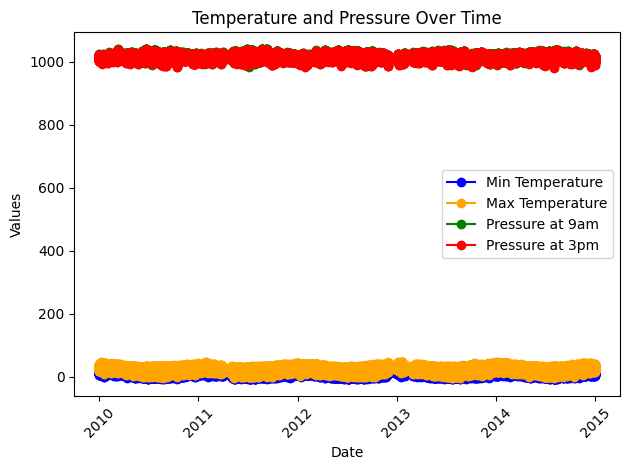

In [18]:
plt.plot(rain_df['MinTemp'], label='Min Temperature', color='blue', marker='o')
plt.plot(rain_df['MaxTemp'], label='Max Temperature', color='orange', marker='o')
plt.plot(rain_df['Pressure9am'], label='Pressure at 9am', color='green', marker='o')
plt.plot(rain_df['Pressure3pm'], label='Pressure at 3pm', color='red', marker='o')
plt.title('Temperature and Pressure Over Time')
plt.xlabel('Date')
plt.ylabel('Values')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Relationship between Humidity and Rainfall

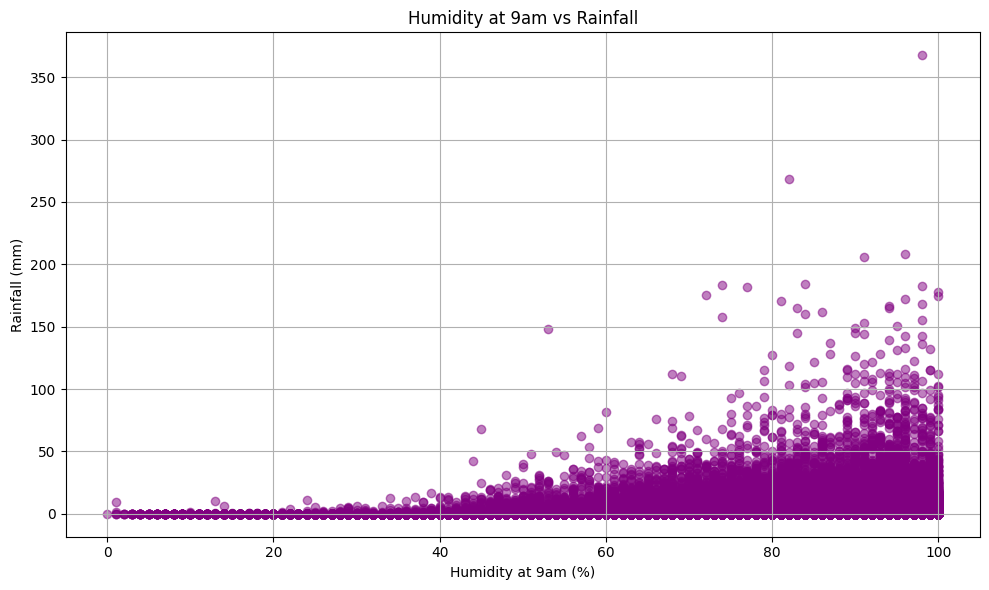

In [19]:
plt.figure(figsize=(10, 6))
plt.scatter(rain_df['Humidity9am'], rain_df['Rainfall'], alpha=0.5, color='purple')
plt.title('Humidity at 9am vs Rainfall')
plt.xlabel('Humidity at 9am (%)')
plt.ylabel('Rainfall (mm)')
plt.grid()
plt.tight_layout()
plt.show()

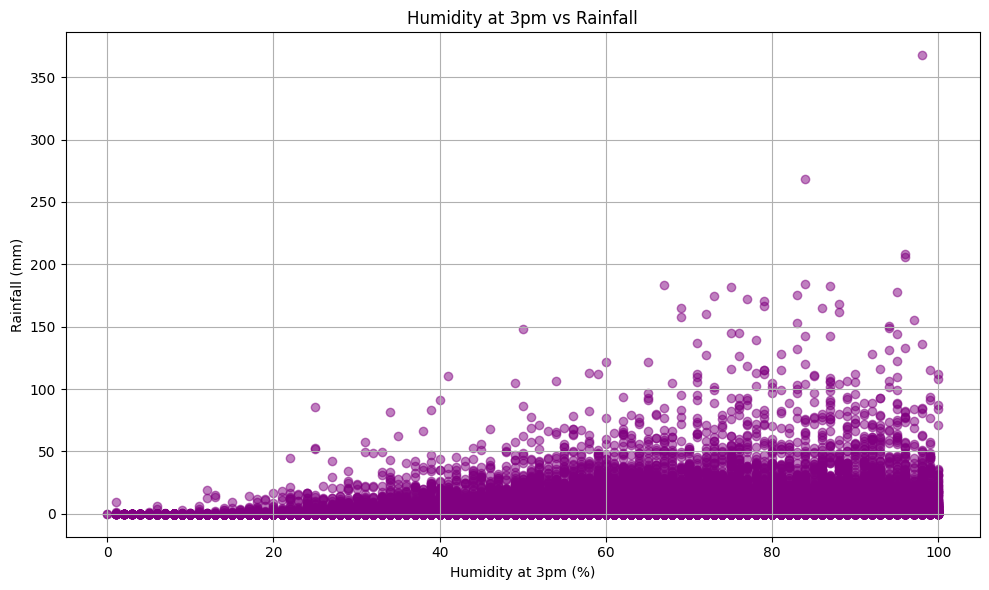

In [20]:
plt.figure(figsize=(10, 6))
plt.scatter(rain_df['Humidity3pm'], rain_df['Rainfall'], alpha=0.5, color='purple')
plt.title('Humidity at 3pm vs Rainfall')
plt.xlabel('Humidity at 3pm (%)')
plt.ylabel('Rainfall (mm)')
plt.grid()
plt.tight_layout()
plt.show()

### Heatmap for Correlation Between Variables

ValueError: could not convert string to float: 'Algiers'

### Bar Plot for Cloud Cover at 9am vs Rainfall

C:\Users\Morsi Store DZ\AppData\Local\Temp\ipykernel_3660\252236804.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Cloud9am', y='Rainfall', data=cloud_rain_data, palette='Blues')


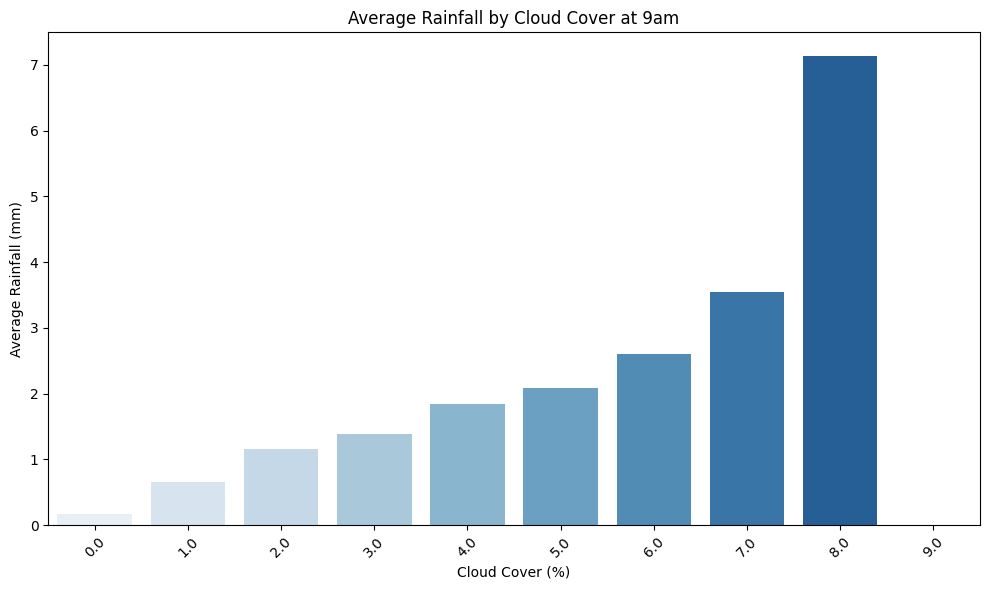

In [23]:
cloud_rain_data = rain_df.groupby('Cloud9am')['Rainfall'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Cloud9am', y='Rainfall', data=cloud_rain_data, palette='Blues')
plt.title('Average Rainfall by Cloud Cover at 9am')
plt.xlabel('Cloud Cover (%)')
plt.ylabel('Average Rainfall (mm)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Bar Plot for Cloud Cover at 3pm vs Rainfall

C:\Users\Morsi Store DZ\AppData\Local\Temp\ipykernel_3660\817420341.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Cloud3pm', y='Rainfall', data=cloud_rain_data, palette='Reds')


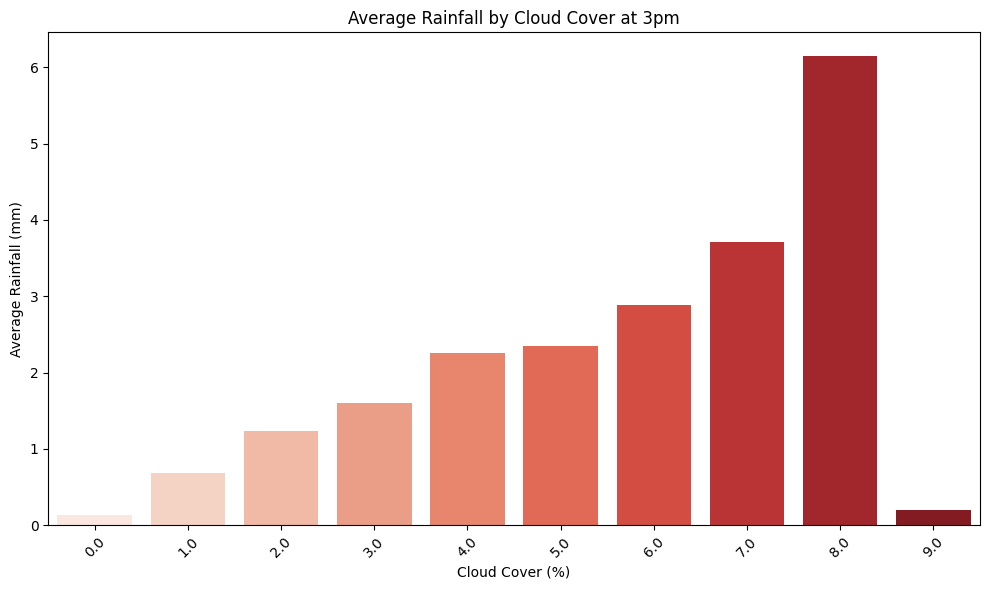

In [28]:
cloud_rain_data = rain_df.groupby('Cloud3pm')['Rainfall'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Cloud3pm', y='Rainfall', data=cloud_rain_data, palette='Reds')
plt.title('Average Rainfall by Cloud Cover at 3pm')
plt.xlabel('Cloud Cover (%)')
plt.ylabel('Average Rainfall (mm)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


###  Stacked Area Chart

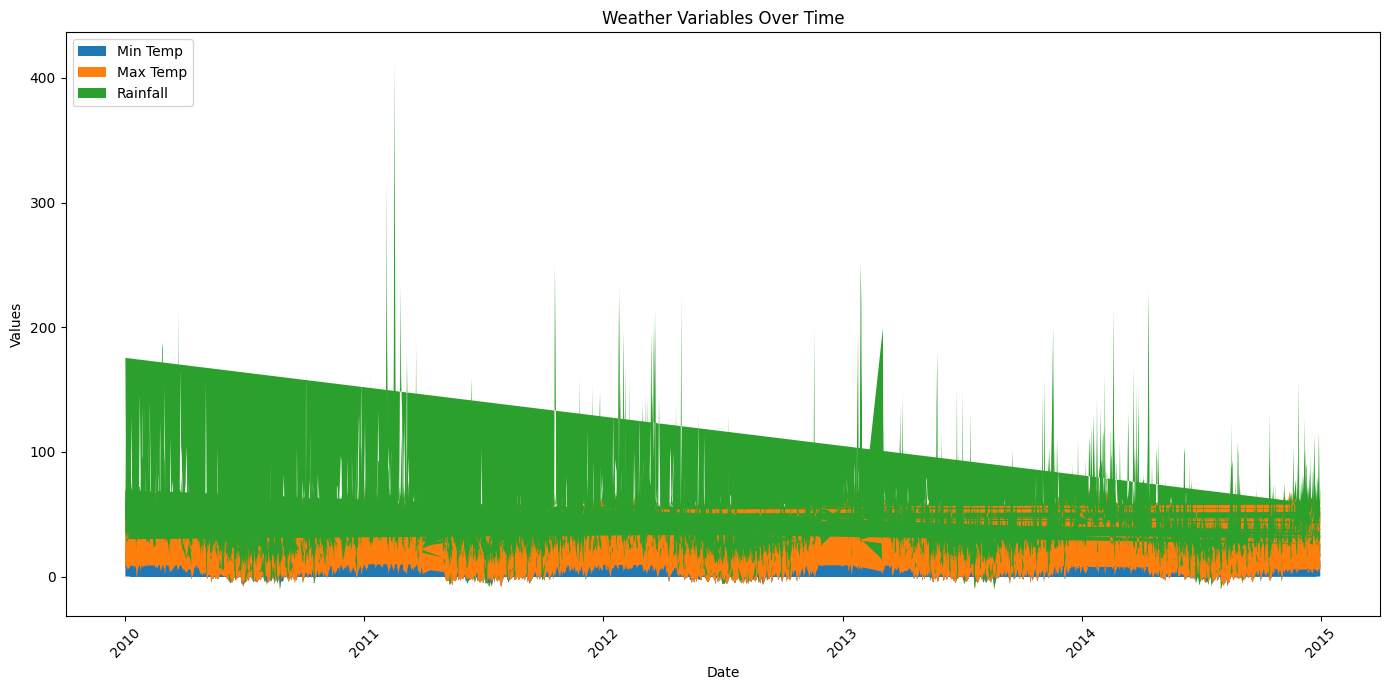

In [29]:
plt.figure(figsize=(14, 7))
plt.stackplot(rain_df.index, rain_df['MinTemp'], rain_df['MaxTemp'], rain_df['Rainfall'], labels=['Min Temp', 'Max Temp', 'Rainfall'])
plt.title('Weather Variables Over Time')
plt.xlabel('Date')
plt.ylabel('Values')
plt.legend(loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


###  Histograms for Distribution

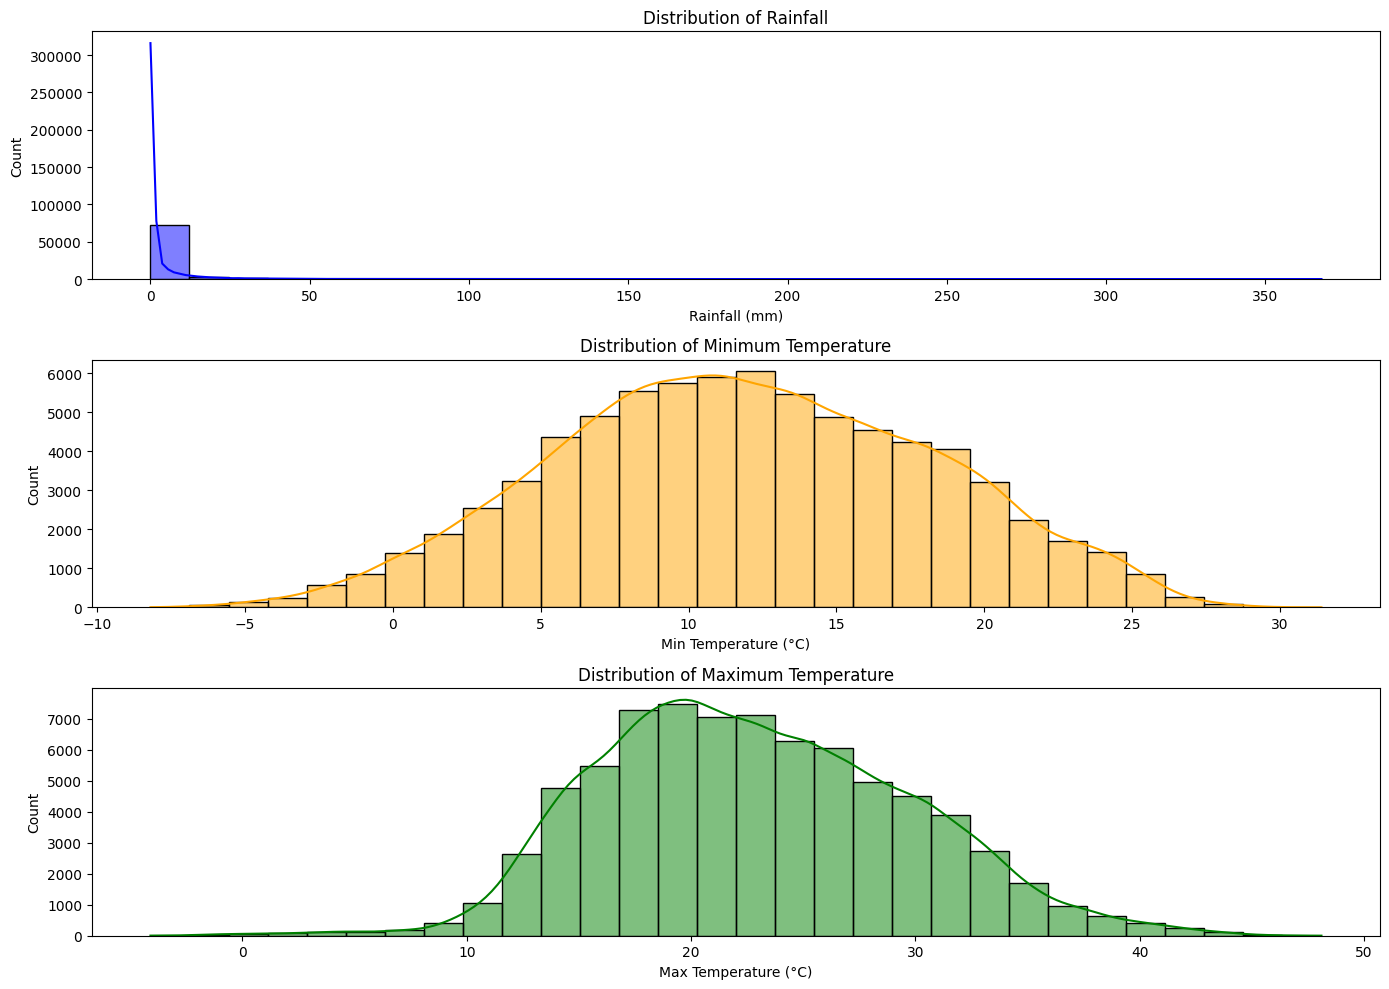

In [30]:
plt.figure(figsize=(14, 10))

plt.subplot(3, 1, 1)
sns.histplot(rain_df['Rainfall'], bins=30, kde=True, color='blue')
plt.title('Distribution of Rainfall')
plt.xlabel('Rainfall (mm)')

plt.subplot(3, 1, 2)
sns.histplot(rain_df['MinTemp'], bins=30, kde=True, color='orange')
plt.title('Distribution of Minimum Temperature')
plt.xlabel('Min Temperature (°C)')

plt.subplot(3, 1, 3)
sns.histplot(rain_df['MaxTemp'], bins=30, kde=True, color='green')
plt.title('Distribution of Maximum Temperature')
plt.xlabel('Max Temperature (°C)')

plt.tight_layout()
plt.show()
